Deteccion de anomalias
    Id_transaccion Cliente_id    Monto_usd
0           TX_000       C-01    64.901425
1           TX_001       C-02    45.852071
2           TX_002       C-01    69.430656
3           TX_003       C-01    95.690896
4           TX_004       C-03    42.975399
..             ...        ...          ...
99          TX_099       C-03    42.962386
100         TX_100       C-02  2500.000000
101         TX_101       C-01  3000.000000
102         TX_102       C-03  4500.000000
103         TX_103       C-01    12.000000

[104 rows x 3 columns]
Duplicados detectados: 2
    Id_transaccion Cliente_id    Monto_usd
0           TX_000       C-01    64.901425
1           TX_001       C-02    45.852071
2           TX_002       C-01    69.430656
3           TX_003       C-01    95.690896
4           TX_004       C-03    42.975399
..             ...        ...          ...
99          TX_099       C-03    42.962386
100         TX_100       C-02  2500.000000
101         TX_101       

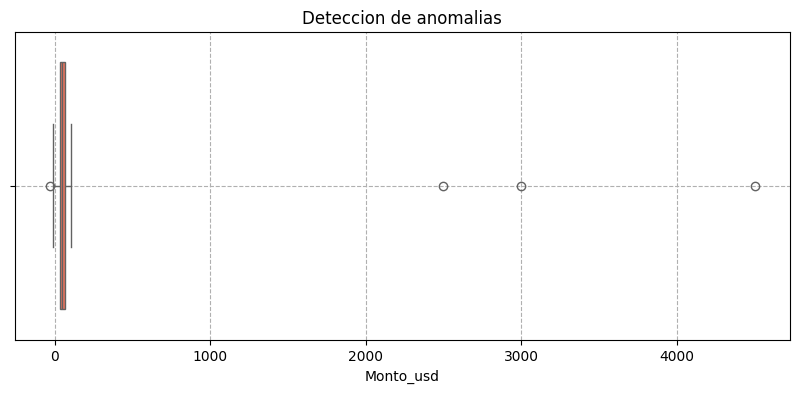

In [ ]:
# Importar librerías necesarias para manipulación de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Deteccion de anomalias")

#Crear un conjunto de datos sintetico de transacciones
#np.random.seed asegura que los resultados sean reproducibles
np.random.seed(42)
montos_normales=np.random.normal(loc=50,scale=30,size=100)

#Añadir unos valores atipicos manuales para simular anomalias en el dataset
montos_outliers=[2500,3000,4500,12]
todos_los_montos=np.concatenate([montos_normales,montos_outliers])

#Construir el DataFrame con identificador de transaccion, cliente y monto en USD
#El DataFrame inicial tiene 104 filas: 100 normales + 4 outliers

df_banco=pd.DataFrame({
    
    'Id_transaccion':[f"TX_{i:03d}" for i in range(104)],
    'Cliente_id':np.random.choice(['C-01','C-02','C-03'],size=104),
    'Monto_usd':todos_los_montos
    
})

print(df_banco)

#Insertar duplicados intencionalmente para demostrar su deteccion
#Se duplican dos filas especificas del DataFrame original
df_banco=pd.concat([df_banco,df_banco.iloc[[5,12]]],ignore_index=True)

#Contar cuantos registros duplicados existen exactamente
duplicados=df_banco.duplicated().sum()
print(f"Duplicados detectados: {duplicados}")

#Eliminar duplicados conservando la primera aparicion de cada registro
#Copiar el resultado para evitar advertencias relacionadas con vistas de pandas
df_limpio=df_banco.drop_duplicates(keep='first').copy()
print(df_limpio)

#Calcular los cuantiles necesarios para el metodo IQR (Interquartile Range)
Q1=df_limpio['Monto_usd'].quantile(0.25)
Q3=df_limpio['Monto_usd'].quantile(0.75)
IQR=Q3-Q1
limite_inferior=Q1-1.5*IQR
limite_superior=Q3+1.5*IQR

print("\nAplicacion del IQR")
print(f"El limite inferior: {limite_inferior}")
print(f"El limite superior: {limite_superior}")

#Seleccionar valores atipicos que queden fuera de los limites de IQR
outliers=df_limpio[(df_limpio['Monto_usd']<limite_inferior)|(df_limpio['Monto_usd']>limite_superior)]

#Mostrar las transacciones sospechosas detectadas
print(f"Se detectaron: {outliers.shape[0]} transacciones sospechosas")
print(outliers[['Id_transaccion','Monto_usd']])

#Visualizar la distribucion de montos y sus outliers con un diagrama de caja
print("Visualizacion")
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_limpio['Monto_usd'], color='tomato')
plt.title('Deteccion de anomalias')
plt.grid(True, linestyle='--')
plt.show()
